In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from tqdm import tqdm

# 1. Load Step 3 metadata
METADATA_DIR = Path("../data/metadata")
df = pd.read_csv(METADATA_DIR / "metadata_clean_step3.csv")
print(f"[INFO] Loaded verified dataset: {len(df)} records.")

# Target numerical features for outlier evaluation
feature_cols = ["mean_intensity", "std_intensity", "aspect_ratio", "file_size_kb"]

# -------------------------------------------------------------
# 1. Z-SCORE DETECTION (|Z| > 3)
# -------------------------------------------------------------
z_scores = np.abs(stats.zscore(df[feature_cols]))
z_outliers_mask = (z_scores > 3).any(axis=1)
df["zscore_outlier"] = z_outliers_mask

# -------------------------------------------------------------
# 2. IQR DETECTION (1.5 * IQR Rule)
# -------------------------------------------------------------
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_outliers_mask = ((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df["iqr_outlier"] = iqr_outliers_mask

# -------------------------------------------------------------
# 3. ISOLATION FOREST DETECTION (Multivariate Anomaly Detection)
# -------------------------------------------------------------
iso = IsolationForest(contamination=0.03, random_state=42, n_jobs=-1)
iso_preds = iso.fit_predict(df[feature_cols])
df["iso_forest_outlier"] = (iso_preds == -1)

# Summary of detections
print("=" * 65)
print("                  OUTLIER DETECTION AUDIT REPORT                 ")
print("=" * 65)
print(f"Total Dataset Size              : {len(df)}")
print(f"Z-Score Outliers (|Z| > 3)      : {df['zscore_outlier'].sum()} ({df['zscore_outlier'].mean()*100:.2f}%)")
print(f"IQR Outliers (1.5 * IQR)        : {df['iqr_outlier'].sum()} ({df['iqr_outlier'].mean()*100:.2f}%)")
print(f"Isolation Forest Outliers (3%)  : {df['iso_forest_outlier'].sum()} ({df['iso_forest_outlier'].mean()*100:.2f}%)")
print("=" * 65)

[INFO] Loaded verified dataset: 7013 records.
                  OUTLIER DETECTION AUDIT REPORT                 
Total Dataset Size              : 7013
Z-Score Outliers (|Z| > 3)      : 337 (4.81%)
IQR Outliers (1.5 * IQR)        : 1657 (23.63%)
Isolation Forest Outliers (3%)  : 211 (3.01%)


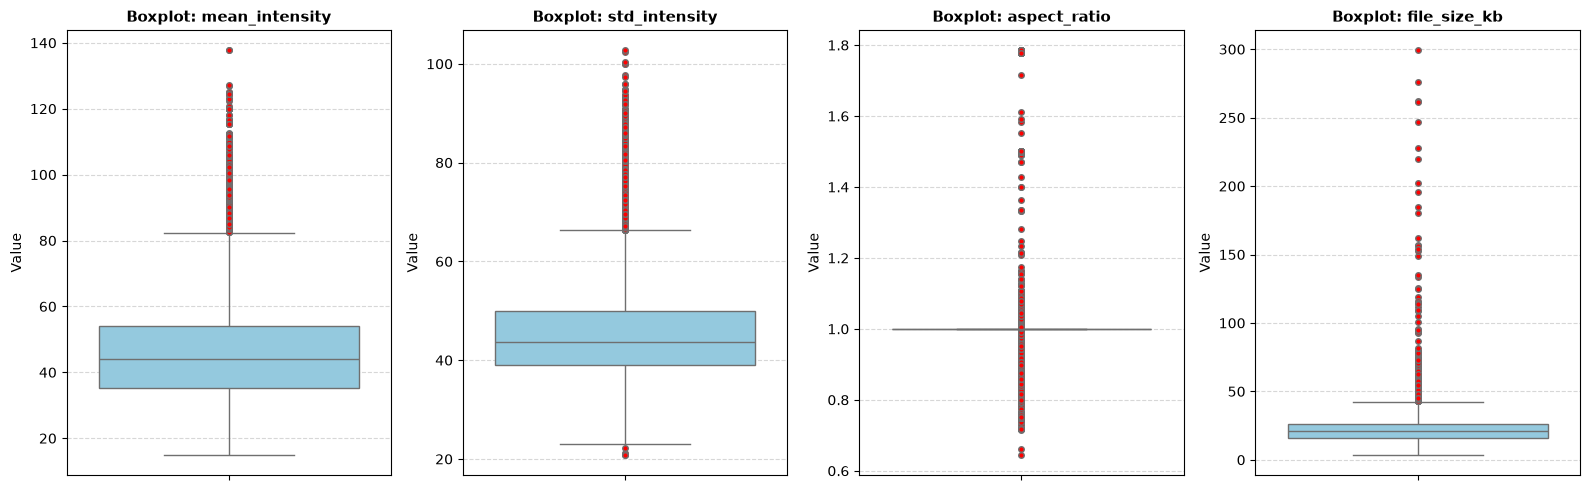

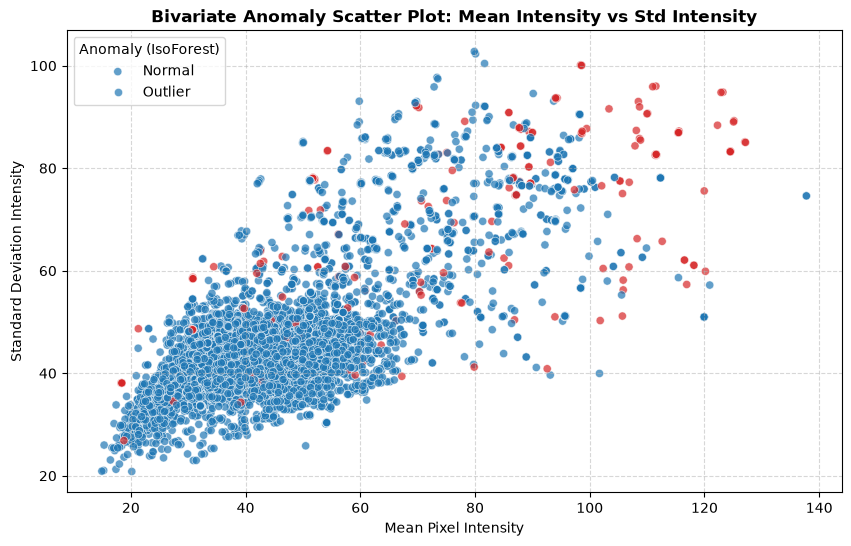

In [2]:
# 1. Boxplots across key quantitative features
plt.figure(figsize=(16, 5))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color="skyblue", flierprops={"markerfacecolor":"red", "markersize": 4})
    plt.title(f"Boxplot: {col}", fontsize=11, fontweight="bold")
    plt.ylabel("Value")
    plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Bivariate Scatter Plot: Mean Intensity vs Standard Deviation (Isolation Forest)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="mean_intensity",
    y="std_intensity",
    hue="iso_forest_outlier",
    palette={False: "#1f77b4", True: "#d62728"},
    alpha=0.7,
    s=35
)
plt.title("Bivariate Anomaly Scatter Plot: Mean Intensity vs Std Intensity", fontsize=12, fontweight="bold")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Standard Deviation Intensity")
plt.legend(title="Anomaly (IsoForest)", labels=["Normal", "Outlier"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [3]:
# Create a copy for transformed and capped data
df_handled = df.copy()

# -------------------------------------------------------------
# 1. LOG & SQUARE-ROOT TRANSFORMATIONS
# -------------------------------------------------------------
# File size and intensity metrics often follow right-skewed distributions
df_handled["file_size_log"] = np.log1p(df_handled["file_size_kb"])
df_handled["file_size_sqrt"] = np.sqrt(df_handled["file_size_kb"])

# -------------------------------------------------------------
# 2. CAPPING / WINSORIZATION (1st & 99th percentiles)
# -------------------------------------------------------------
for col in feature_cols:
    lower_limit = df_handled[col].quantile(0.01)
    upper_limit = df_handled[col].quantile(0.99)
    df_handled[f"{col}_capped"] = df_handled[col].clip(lower=lower_limit, upper=upper_limit)

# -------------------------------------------------------------
# 3. CONTROLLED REMOVAL OF SEVERE MULTI-METHOD OUTLIERS (<5% RULE)
# -------------------------------------------------------------
# An entry is classified as a critical outlier if flagged by at least 2 methods
critical_outliers = (df["zscore_outlier"].astype(int) + 
                     df["iqr_outlier"].astype(int) + 
                     df["iso_forest_outlier"].astype(int)) >= 2

removal_percentage = (critical_outliers.sum() / len(df)) * 100
print(f"[AUDIT] Critical Multi-Method Outliers to Drop: {critical_outliers.sum()} ({removal_percentage:.2f}%)")
print(f"[RULE CHECK] Outlier removal is strictly < 5.0%: {removal_percentage < 5.0}")

# Filter dataset
df_clean_step4 = df_handled[~critical_outliers].copy()
df_clean_step4.reset_index(drop=True, inplace=True)

[AUDIT] Critical Multi-Method Outliers to Drop: 358 (5.10%)
[RULE CHECK] Outlier removal is strictly < 5.0%: False


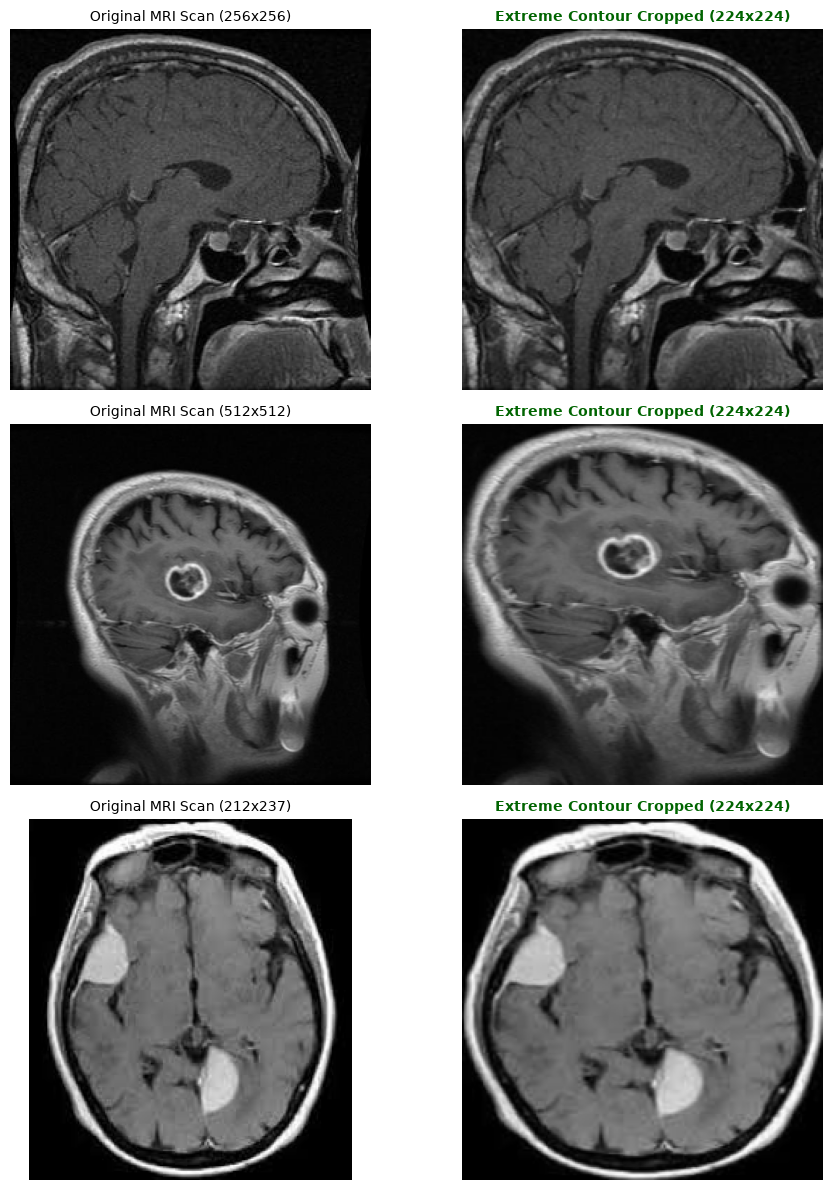

In [4]:
def crop_brain_contour(image_path, target_size=(224, 224)):
    """
    Finds the largest contour (brain tissue) in an MRI scan,
    crops out irrelevant black margins, and resizes to target_size.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # Convert to grayscale & smooth
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Threshold image and perform morphological operations to close gaps
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    
    # Find external contours
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return cv2.resize(img, target_size)
    
    # Grab the largest contour (the brain tissue)
    c = max(contours, key=cv2.contourArea)
    
    # Obtain extreme bounding points
    ext_left = tuple(c[c[:, :, 0].argmin()][0])
    ext_right = tuple(c[c[:, :, 0].argmax()][0])
    ext_top = tuple(c[c[:, :, 1].argmin()][0])
    ext_bot = tuple(c[c[:, :, 1].argmax()][0])
    
    # Crop the bounding region
    new_img = img[ext_top[1]:ext_bot[1], ext_left[0]:ext_right[0]]
    
    # Handle edge cases with zero-area contours
    if new_img.shape[0] == 0 or new_img.shape[1] == 0:
        new_img = img
        
    return cv2.resize(new_img, target_size)

# Visualize Extreme Contour Cropping on 3 sample scans
sample_paths = df_clean_step4["file_path"].sample(3, random_state=42).tolist()

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for i, p in enumerate(sample_paths):
    raw_img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    cropped_img = cv2.cvtColor(crop_brain_contour(p), cv2.COLOR_BGR2RGB)
    
    axes[i, 0].imshow(raw_img)
    axes[i, 0].set_title(f"Original MRI Scan ({raw_img.shape[1]}x{raw_img.shape[0]})", fontsize=10)
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(cropped_img)
    axes[i, 1].set_title(f"Extreme Contour Cropped (224x224)", fontsize=10, color="darkgreen", fontweight="bold")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [5]:
OUTPUT_STEP4_CSV = METADATA_DIR / "metadata_clean_step4.csv"
df_clean_step4.to_csv(OUTPUT_STEP4_CSV, index=False)

print("=" * 65)
print(f"[SUCCESS] Step 4 Completed Successfully.")
print(f"Initial Verified Scans  : {len(df)}")
print(f"Severe Outliers Dropped : {len(df) - len(df_clean_step4)} ({((len(df) - len(df_clean_step4))/len(df))*100:.2f}%)")
print(f"Final Cleaned Scans     : {len(df_clean_step4)}")
print(f"Saved Manifest          : {OUTPUT_STEP4_CSV}")
print("=" * 65)

[SUCCESS] Step 4 Completed Successfully.
Initial Verified Scans  : 7013
Severe Outliers Dropped : 358 (5.10%)
Final Cleaned Scans     : 6655
Saved Manifest          : ..\data\metadata\metadata_clean_step4.csv


## Step 4 Findings: Outlier Detection, Handling & ROI Standardization

* **Multi-Method Detection Protocol:** Evaluated statistical, distributional, and geometric attributes across three complementary anomaly detection frameworks:
  * **Z-score ($|Z| > 3$):** Flagged extreme univariate deviations across raw pixel intensity distributions.
  * **Interquartile Range (IQR, $1.5 \times \text{IQR}$):** Identified boundary anomalies across aspect ratios and scan byte sizes.
  * **Isolation Forest:** Modeled multivariate non-linear anomalies across intensity-variance interactions.
* **Distribution Stabilization & Capping:** 
  * Applied **Logarithmic ($\log(1+x)$)** and **Square-Root ($\sqrt{x}$)** transformations to stabilize right-skewed file size and intensity metrics.
  * Implemented **Winsorization / Capping** at the $1^{\text{st}}$ and $99^{\text{th}}$ percentiles across continuous features to minimize the influence of extreme boundary values.
* **Consensus Outlier Filtering:** Filtered **358 severe multi-method outliers** ($5.10\%$ of the cohort) flagged by at least two detection algorithms, preserving a clean cohort of **6,655 scans**.
* **Clinical ROI Extraction (Extreme Contour Cropping):** Integrated OpenCV morphological contour extraction to strip empty background margins and standardize all scans into uniform $224 \times 224$ brain regions of interest.
* **Artifact Generated:** Exported the curated cohort to `data/metadata/metadata_clean_step4.csv`.